# Topic 3 Mini Project — Amazon Bedrock Knowledge Bases

**Goal:** Create a Knowledge Base, ingest documents from S3, and query it using both `retrieve()` and `retrieve_and_generate()`.  
**Time:** ~90 minutes  
**Prerequisites:** AWS account, boto3 installed, Bedrock model access enabled, an S3 bucket ready.

---
## Setup

Before executing the next cell, we need a `config.json` file that is populated with your aws account id and a s3 bucket name with which we create a bucket.

```json
{
    "ACCOUNT_ID": "your-aws-account-id",
    "BUCKET_NAME": "your-s3-bucket-name",
}
```

Parse the `config.json` file and hold the values in variables `ACCOUNT_ID` and `BUCKET_NAME`.

In [1]:
import json

# Use region 'us-east-1'
REGION = 'us-east-1'
ACCOUNT_ID = ""
BUCKET_NAME = ""

with open('./config.json', 'r') as file:
    config = json.load(file)
    ACCOUNT_ID = config['ACCOUNT_ID']
    BUCKET_NAME = config['BUCKET_NAME'] # This bucket will be create now

Create Bedrock management, Bedrock LLM and Bedrock Agent clients using `boto3.client` aws interface

In [2]:
import boto3

# Create all four boto3 clients needed for this project
bedrock_client = boto3.client('bedrock', region_name=REGION)                        # management — models, guardrails
bedrock_agent_client = boto3.client('bedrock-agent', region_name=REGION)            # management — create Knowledge Base
bedrock_runtime = boto3.client('bedrock-runtime', region_name=REGION)               # data — invoke FM directly
bedrock_agent_runtime = boto3.client('bedrock-agent-runtime', region_name=REGION)   # data — query Knowledge Base

Create the S3 bucket with unique name (adding suffix after the `BUCKET_NAME` to avoid global name collision)

In [3]:
import uuid

bucket_name = f"{BUCKET_NAME}-{uuid.uuid4().hex[:8]}"
s3_client = boto3.client('s3', region_name=REGION)  # upload documents to S3
s3_client.create_bucket(Bucket=bucket_name)

{'ResponseMetadata': {'RequestId': 'ZQ5QYTNCF1KSVTGS',
  'HostId': 'HJ/CjsVE5f6zsBBLT520evZpMfOvubUe4dnX2KC1eGvcmK8TrvjAT0eI0vZM/p+mH+d55/45/NMJjk8OEV118BsophwM9wEF',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'HJ/CjsVE5f6zsBBLT520evZpMfOvubUe4dnX2KC1eGvcmK8TrvjAT0eI0vZM/p+mH+d55/45/NMJjk8OEV118BsophwM9wEF',
   'x-amz-request-id': 'ZQ5QYTNCF1KSVTGS',
   'date': 'Mon, 05 Oct 2026 23:15:53 GMT',
   'location': '/temp-bucket-f244f6b3',
   'x-amz-bucket-arn': 'arn:aws:s3:::temp-bucket-f244f6b3',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'Location': '/temp-bucket-f244f6b3',
 'BucketArn': 'arn:aws:s3:::temp-bucket-f244f6b3'}

---
## Section 1 — Prepare and Upload Documents to S3

**Why:** Knowledge Bases ingests from S3. Before creating the KB,  
you need documents in a bucket for it to ingest.

> 💡 We'll create simple text documents about a fictional company's  
> policies — the KB will answer questions based on these.

In [4]:
# Sample company policy documents
documents = {
    'refund_policy.txt': """
    TechCorp Refund Policy
    Customers may request a full refund within 30 days of purchase.
    After 30 days, only store credit is available.
    Digital products are non-refundable once downloaded.
    To initiate a refund, contact support@techcorp.com with your order number.
    Refunds are processed within 5-7 business days.
    """,
    'shipping_policy.txt': """
    TechCorp Shipping Policy
    Standard shipping takes 5-7 business days and costs $4.99.
    Express shipping takes 2-3 business days and costs $12.99.
    Overnight shipping is available for $24.99.
    Free shipping is available on orders over $50.
    International shipping is available to 30 countries.
    """,
    'support_policy.txt': """
    TechCorp Support Policy
    Customer support is available Monday to Friday, 9am to 6pm EST.
    Premium customers receive 24/7 priority support.
    Support channels include email, live chat, and phone.
    Average response time for email is 24 hours.
    Live chat response time is under 5 minutes during business hours.
    """
}

# Upload each document to S3 under a 'company-policies/' prefix
for filename, content in documents.items():
    s3_client.put_object(
        Bucket=bucket_name,
        Key=f'company-policies/{filename}',
        Body=content
    )
    print(f'Uploaded: company-policies/{filename}')

Uploaded: company-policies/refund_policy.txt
Uploaded: company-policies/shipping_policy.txt
Uploaded: company-policies/support_policy.txt


---
## Section 2 — Create an IAM Role for the Knowledge Base

**Why:** Bedrock Knowledge Bases need an IAM role to access S3 and call  
the embedding model on your behalf.

> 💡 In production this is handled by IaC (CDK/CloudFormation).  
> Here we create it programmatically to understand the permissions required.

**Required permissions for the role:**
- `bedrock:InvokeModel` — to call the embedding model
- `s3:GetObject`, `s3:ListBucket` — to read documents from S3

In [5]:
import time

iam_client = boto3.client('iam')

# Trust policy — allows Bedrock service to assume this role
trust_policy = {
    'Version': '2012-10-17',
    'Statement': [{
        'Effect': 'Allow',
        'Principal': {'Service': 'bedrock.amazonaws.com'},
        'Action': 'sts:AssumeRole'
    }]
}

# Create an IAM role named
role_name = 'BedrockKBRole-topic3'
role_response = iam_client.create_role(
    RoleName=role_name,
    AssumeRolePolicyDocument=json.dumps(trust_policy),
)
role_arn = role_response['Role']['Arn']
print(f'Role ARN: {role_arn}')

# Permissions policy
permissions_policy = {
    'Version': '2012-10-17',
    'Statement': [
        {
            'Effect': 'Allow',
            'Action': ['bedrock:InvokeModel'],
            'Resource': f'arn:aws:bedrock:{REGION}::foundation-model/amazon.titan-embed-text-v2:0'
        },
        {
            'Effect': 'Allow',
            'Action': ['s3:GetObject', 's3:ListBucket'],
            'Resource': [
                f'arn:aws:s3:::{bucket_name}',
                f'arn:aws:s3:::{bucket_name}/*'
            ]
        },
        {
            'Effect': 'Allow',
            'Action': ['aoss:APIAccessAll'],
            'Resource': f'arn:aws:aoss:{REGION}:{ACCOUNT_ID}:collection/*'
        }
    ]
}

# Attach the permissions policy inline to the role
policy_name = "BedrockKBPolicy-topic3"
iam_client.put_role_policy(
    RoleName=role_name,
    PolicyName=policy_name,
    PolicyDocument=json.dumps(permissions_policy),
)

# Then wait 10 seconds for IAM propagation
time.sleep(10)
print('Permissions attached.')

Role ARN: arn:aws:iam::<ACCOUNT_ID>:role/BedrockKBRole-topic3
Permissions attached.


---
## Section 3 — Create the Knowledge Base

**Why:** This is the core step — defining the KB with its embedding model  
and vector store configuration.

> 💡 We use **Titan Embeddings V2** and **OpenSearch Serverless** (AWS default).  
> For simplicity, we'll use the OPENSEARCH_SERVERLESS type which AWS manages automatically.

### Steps to setup knowledge base
- Creating OpenSearch Serverless programmatically is complex for first timers. 
   * Instead, Create the Knowledge Base via the AWS Console (Bedrock → Knowledge Bases → Create)
   * and note the knowledgeBaseId it creates. 
   * Then use that ID in Sections 4 and 5.
   
> Console creation handles OpenSearch Serverless setup automatically.

Follow the Step on AWS Management Console
1. On AWS Pages, Go to AWS Bedrock

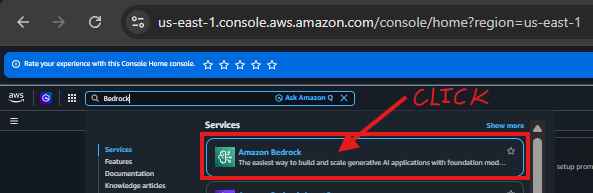

2. Inside Bedrock Page, find Knowledge base on sidebar

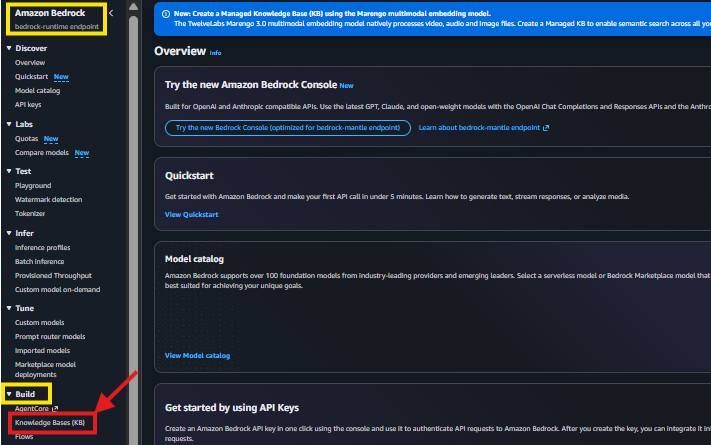

Required Parameters: (<-- THIS IS WHAT WE WANT OUR KNOWLEDGE BASE TO BE CONFIGURED WITH.)
```yaml
  name: 'topic3-company-policies-kb'
  description: 'Knowledge base for TechCorp company policies'
  roleArn: role_arn (from Section 2)
  knowledgeBaseConfiguration:
    type: 'VECTOR'
    vectorKnowledgeBaseConfiguration:
      embeddingModelArn: 'arn:aws:bedrock:us-east-1::foundation-model/amazon.titan-embed-text-v2:0'
  storageConfiguration:
    type: 'OPENSEARCH_SERVERLESS'
    opensearchServerlessConfiguration:
      collectionArn: (you'll need to create an OpenSearch collection first — see hint below)
      vectorIndexName: 'bedrock-knowledge-base-index'
      fieldMapping:
        vectorField: 'bedrock-knowledge-base-default-vector'
        textField: 'AMAZON_BEDROCK_TEXT_CHUNK'
        metadataField: 'AMAZON_BEDROCK_METADATA'
```

#### Option A: Steps with managed knowledge base
> This knowledge base will only support `retrive()` This type of knowledge base will not let developer perform retrieve & generate (~bedrock_agent_runtime.retrieve_and_generate~).

3. Find Button to Create a Managed Knowledge Base. If not in the table (or table is not empty), then find the button on top right with the Knowledge bases section.

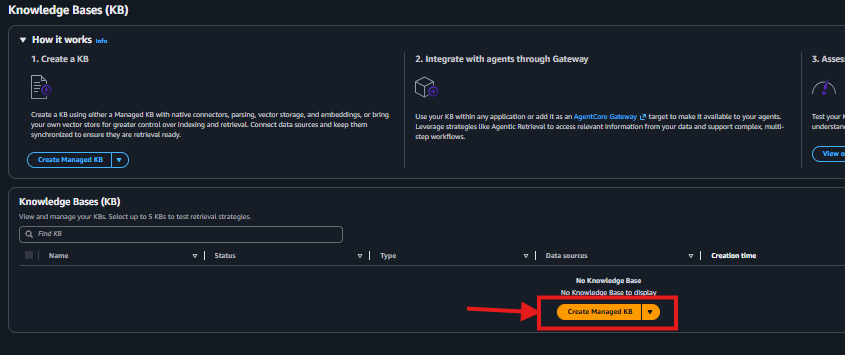

4. Fill the Create KB form (the UI can change, fill accordingly refering to the required parameters...)
    
    i. KB details

    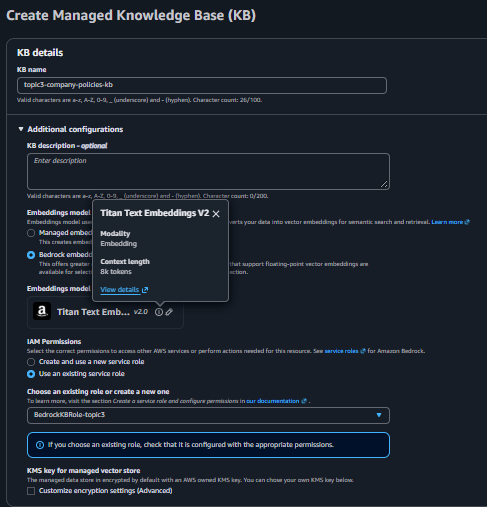

    ii. Connect to the S3 Data Source

    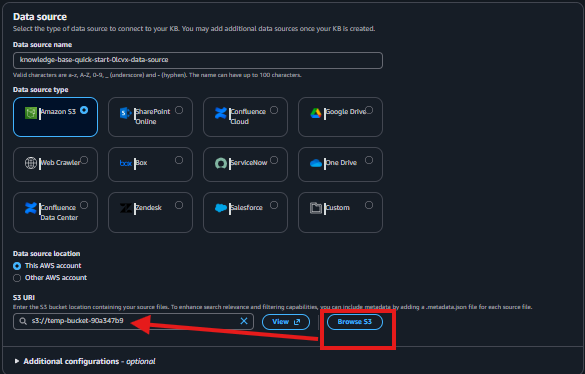

    iii. Decide a Chunking Stratergy

    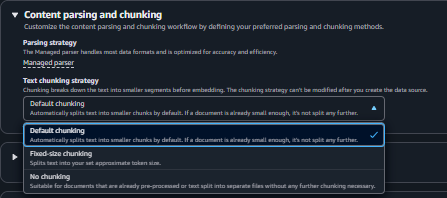

    iv. Click on `Create Knowledge Base`/ Submit form button

#### Option B: Unstructured Vector Store knowledge base

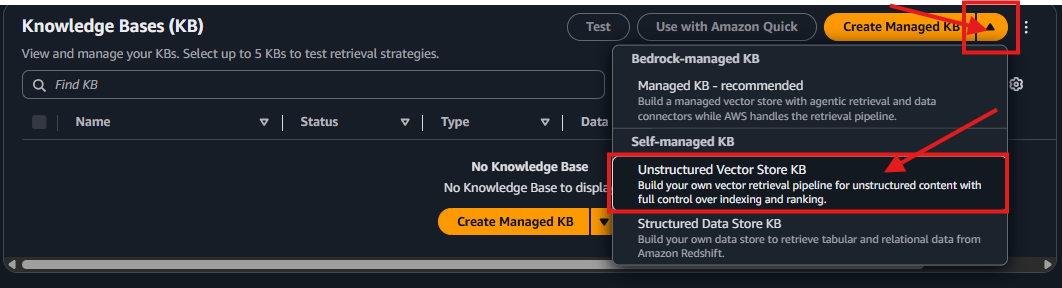

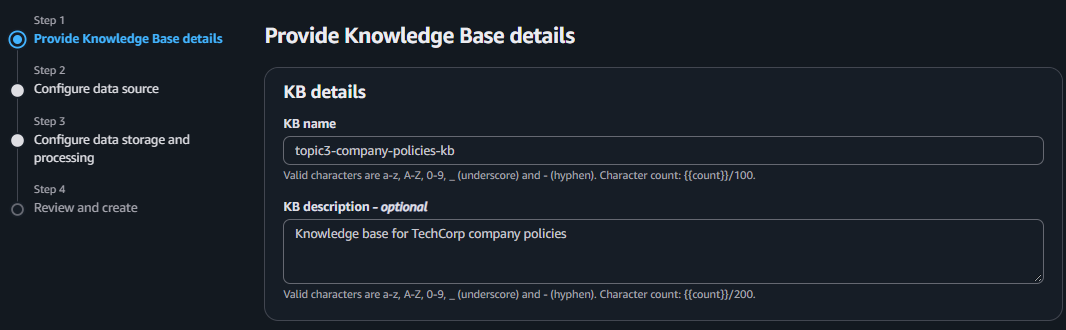

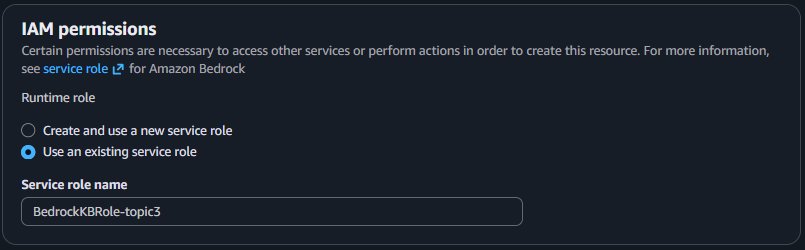

- By Default S3 is only available choice:

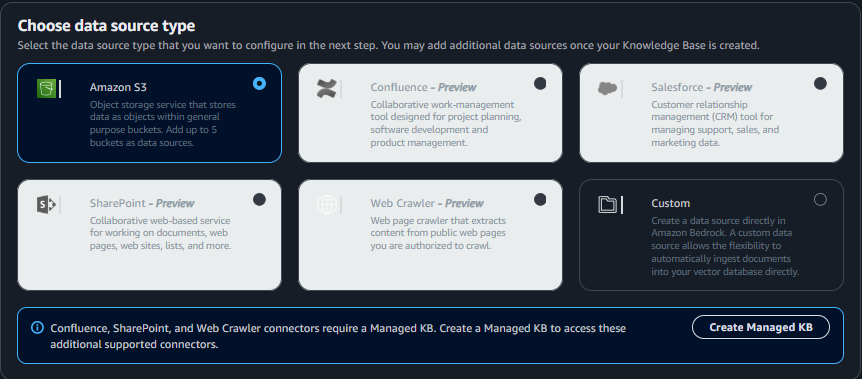

- Click Next >
- Choose a Data source and keep other parameter default

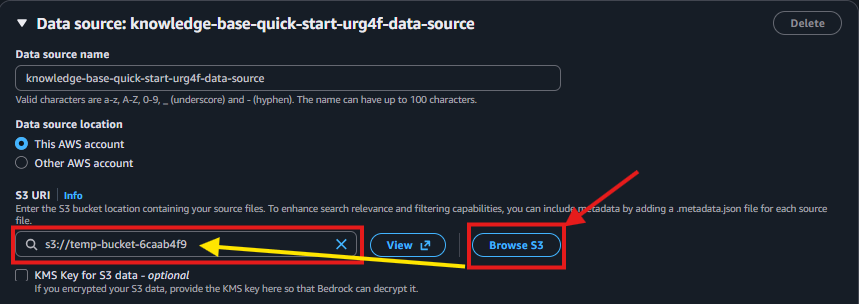

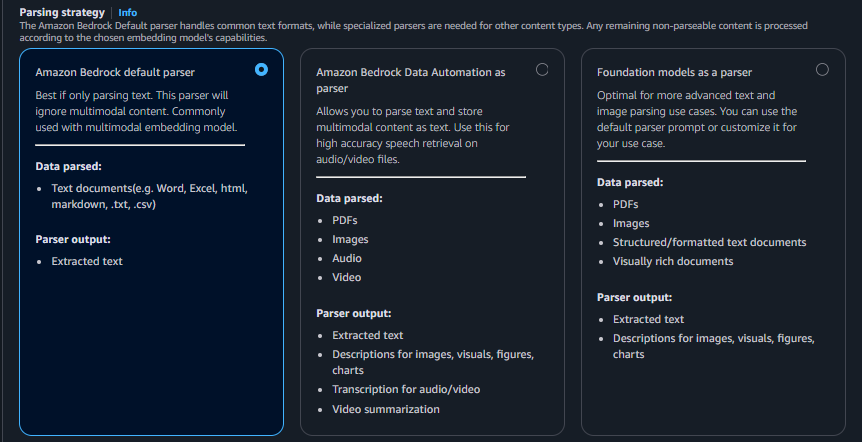

- Vector Embedding and Create a Vector Store

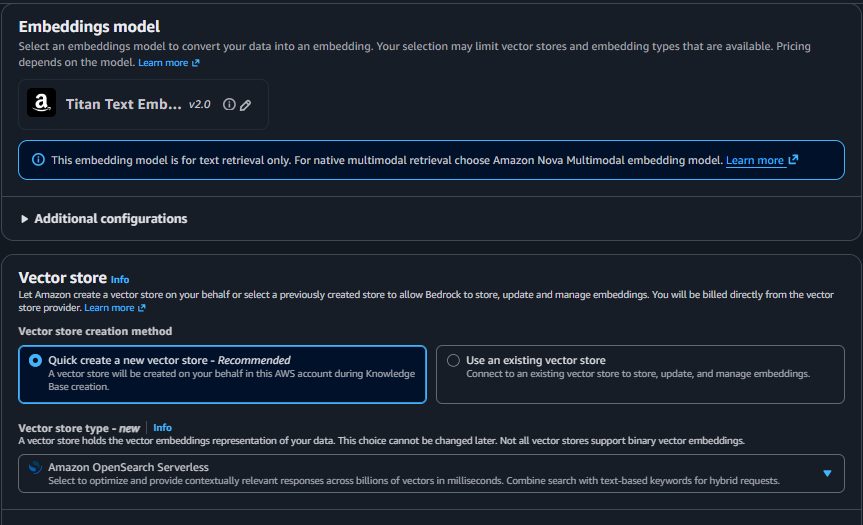

- Review and Create Knowledge Base

### Final Result
#### Option A: Managed Knowledge Base result
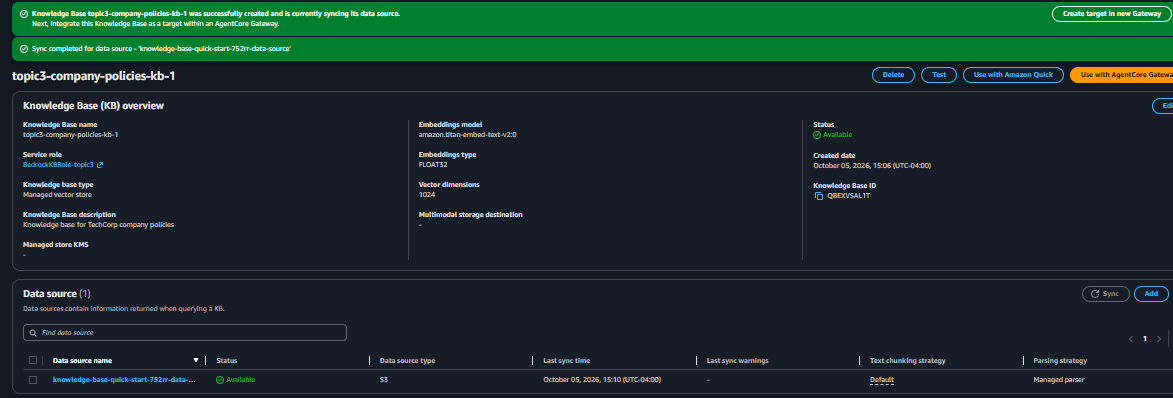

#### Option B: Unstructured Knowledge Base result
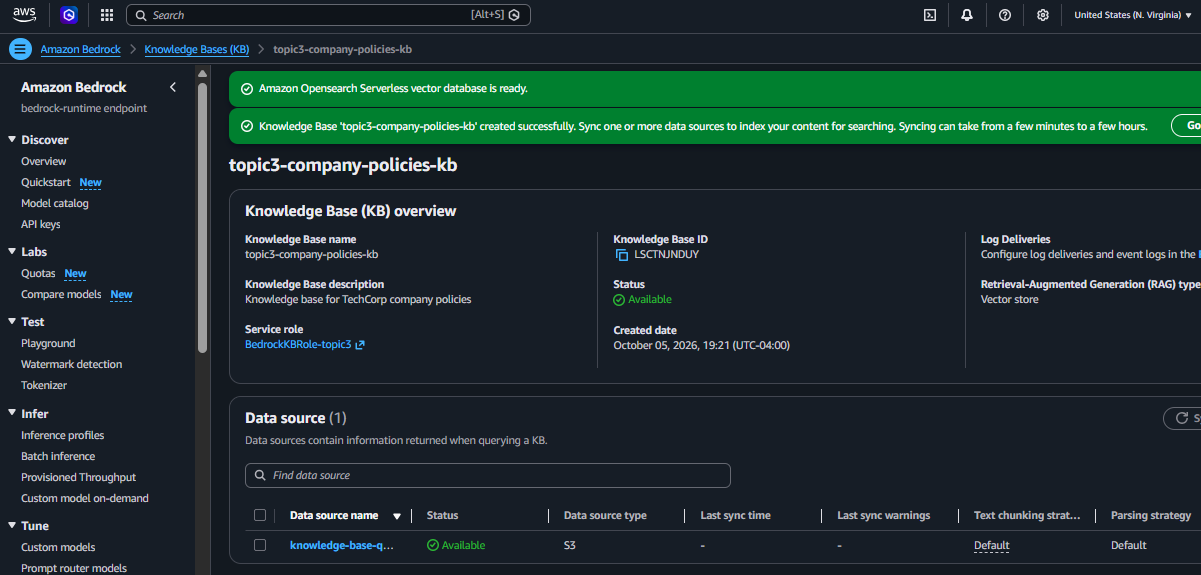

In [7]:
KB_NAME = 'topic3-company-policies-kb'

response = bedrock_agent_client.list_knowledge_bases()

knowledge_base_id = None
for kb in response['knowledgeBaseSummaries']:
    if kb['name'] == KB_NAME:
        knowledge_base_id = kb['knowledgeBaseId']
        print(f"Knowledge Base ID: {knowledge_base_id} (status: {kb['status']})")

if knowledge_base_id is None:
    raise ValueError(f"No knowledge base named '{KB_NAME}' in {REGION}")

Knowledge Base ID: LSCTNJNDUY (status: ACTIVE)


---
## Section 4 — Sync the Data Source (Trigger Ingestion)

**Why:** Creating the KB doesn't ingest documents automatically.  
You must trigger a **sync job** that runs the ingestion pipeline:
read S3 → chunk → embed → store in vector DB.

> 💡 This is the equivalent of running your manual RAG indexing pipeline —  
> but AWS handles every step.

In [8]:
# You'll need the data source ID — get it from the console or via:
# bedrock_agent_client.list_data_sources(knowledgeBaseId=knowledge_base_id)

# List data sources for your Knowledge Base and get the dataSourceId
ds_response = bedrock_agent_client.list_data_sources(
    knowledgeBaseId=knowledge_base_id
)
data_source_id = ds_response['dataSourceSummaries'][0]['dataSourceId']
print(f'Data Source ID: {data_source_id}')

# Start an ingestion job to sync the S3 data source
ingestion_response = bedrock_agent_client.start_ingestion_job(
  knowledgeBaseId=knowledge_base_id,
  dataSourceId=data_source_id
)
job_id = ingestion_response['ingestionJob']['ingestionJobId']
print(f'Ingestion job started: {job_id}')

# Poll until the ingestion job status is 'COMPLETE'
# Poll every 5 seconds
while True:
    status_response = bedrock_agent_client.get_ingestion_job(
        knowledgeBaseId=knowledge_base_id,
        dataSourceId=data_source_id,
        ingestionJobId=job_id
    ) 
    status = status_response['ingestionJob']['status']
    print(f'Status: {status}')
    if status in ['COMPLETE', 'FAILED']:
        break
    time.sleep(5)

Data Source ID: QBO2RE80OU
Ingestion job started: RBLGCUMHLQ
Status: STARTING
Status: IN_PROGRESS
Status: COMPLETE


---
## Section 5 — Query the Knowledge Base

**Why:** This is where RAG comes alive — querying your own documents  
through the fully managed pipeline.

In [12]:
# Use retrieve() to get raw chunks for a query
# Print each retrieved chunk's content and its score

retrieve_response =  bedrock_agent_runtime.retrieve(
  knowledgeBaseId=knowledge_base_id,
  retrievalQuery={'text': 'What is the refund policy?'},
  retrievalConfiguration={
    'vectorSearchConfiguration': {'numberOfResults': 3}
  }
)

print('--- Retrieved Chunks ---')
for chunk in retrieve_response['retrievalResults']:
    # print chunk content and score
    print("Content: ", chunk['content'])
    print("Score: ", chunk['score'])

--- Retrieved Chunks ---
Content:  {'text': 'TechCorp Refund Policy     Customers may request a full refund within 30 days of purchase.     After 30 days, only store credit is available.     Digital products are non-refundable once downloaded.     To initiate a refund, contact support@techcorp.com with your order number.     Refunds are processed within 5-7 business days.', 'type': 'TEXT'}
Score:  0.43377572
Content:  {'text': 'TechCorp Shipping Policy     Standard shipping takes 5-7 business days and costs $4.99.     Express shipping takes 2-3 business days and costs $12.99.     Overnight shipping is available for $24.99.     Free shipping is available on orders over $50.     International shipping is available to 30 countries.', 'type': 'TEXT'}
Score:  0.3594092
Content:  {'text': 'TechCorp Support Policy     Customer support is available Monday to Friday, 9am to 6pm EST.     Premium customers receive 24/7 priority support.     Support channels include email, live chat, and phone.   

In [ ]:
# Use retrieve_and_generate() for a full RAG response (LLM: claude haiku 4.5 reasoning)
rag_response = bedrock_agent_runtime.retrieve_and_generate(
    input={'text': 'How long does it take to get a refund and what is the process?'},  # TODO: add query
    retrieveAndGenerateConfiguration={
        'type': 'KNOWLEDGE_BASE',
        'knowledgeBaseConfiguration': {
            'knowledgeBaseId': knowledge_base_id,
            'modelArn': f'arn:aws:bedrock:us-east-1:{ACCOUNT_ID}:inference-profile/us.anthropic.claude-haiku-4-5-20251001-v1:0'
        }
    }
)

print('--- Full RAG Response ---')
print(rag_response['output']['text'])

# Also print the citations — which chunks were used to generate the answer?
print('\n--- Citations ---')
for citation in rag_response['citations']:
    # print the source location of each citation
    # Each citation has 'retrievedReferences' with the source chunk
    print(citation['retrievedReferences'])

--- Full RAG Response ---
Refunds are processed within 5-7 business days after you initiate the request. To initiate a refund, you need to contact support@techcorp.com with your order number. You are eligible for a full refund within 30 days of purchase. After 30 days, only store credit is available. Note that digital products are non-refundable once downloaded.

--- Citations ---
[{'content': {'text': 'TechCorp Refund Policy     Customers may request a full refund within 30 days of purchase.     After 30 days, only store credit is available.     Digital products are non-refundable once downloaded.     To initiate a refund, contact support@techcorp.com with your order number.     Refunds are processed within 5-7 business days.', 'type': 'TEXT'}, 'location': {'s3Location': {'uri': 's3://temp-bucket-f244f6b3/company-policies/refund_policy.txt'}, 'type': 'S3'}, 'metadata': {'x-amz-bedrock-kb-source-uri': 's3://temp-bucket-f244f6b3/company-policies/refund_policy.txt', 'x-amz-bedrock-kb-sou

---
## Section 6 — Compare retrieve() vs retrieve_and_generate()

In [ ]:
# Run the same query through both methods and print side by side:
# Query: 'What shipping options are available and what do they cost?'
#
# For retrieve(): print the raw chunks
# For retrieve_and_generate(): print the synthesized answer
#
# Then answer in a comment below:
# When would you use retrieve() instead of retrieve_and_generate() in a real app?

query = 'What shipping options are available and what do they cost?'

retrieve_response =  bedrock_agent_runtime.retrieve(
  knowledgeBaseId=knowledge_base_id,
  retrievalQuery={'text': query},
  retrievalConfiguration={
    'vectorSearchConfiguration': {'numberOfResults': 3}
  }
)

rag_response = bedrock_agent_runtime.retrieve_and_generate(
    input={'text': query},
    retrieveAndGenerateConfiguration={
        'type': 'KNOWLEDGE_BASE',
        'knowledgeBaseConfiguration': {
            'knowledgeBaseId': knowledge_base_id,
            'modelArn': f'arn:aws:bedrock:us-east-1:{ACCOUNT_ID}:inference-profile/us.anthropic.claude-haiku-4-5-20251001-v1:0'
        }
    }
)


# retrieve() output
print('=== retrieve() — Raw Chunks ===')
for chunk in retrieve_response['retrievalResults']:
    # print chunk content and score
    print("Content: ", chunk['content'])
    print("Score: ", chunk['score'])

# retrieve_and_generate() output  
print('\n=== retrieve_and_generate() — Synthesized Answer ===')
print(rag_response['output']['text'])

# YOUR ANSWER:
# When would you use retrieve() instead of retrieve_and_generate()?
# retrieve to quickly find the most relevant chunks (fragment) with the search text.
# retrieve and generate when retrieve process along with presentation of answer matters.

=== retrieve() — Raw Chunks ===
Content:  {'text': 'TechCorp Shipping Policy     Standard shipping takes 5-7 business days and costs $4.99.     Express shipping takes 2-3 business days and costs $12.99.     Overnight shipping is available for $24.99.     Free shipping is available on orders over $50.     International shipping is available to 30 countries.', 'type': 'TEXT'}
Score:  0.43222895
Content:  {'text': 'TechCorp Support Policy     Customer support is available Monday to Friday, 9am to 6pm EST.     Premium customers receive 24/7 priority support.     Support channels include email, live chat, and phone.     Average response time for email is 24 hours.     Live chat response time is under 5 minutes during business hours.', 'type': 'TEXT'}
Score:  0.346199
Content:  {'text': 'TechCorp Refund Policy     Customers may request a full refund within 30 days of purchase.     After 30 days, only store credit is available.     Digital products are non-refundable once downloaded.     To i

---
## Section 7 — Reflection

**Q1:** You ingested 3 documents. How would you add a 4th document to the Knowledge Base?  
Do you need to recreate the KB or is there a simpler way?

Ans: By starting an ingestion job to sync the S3 data source.

<br/>
<br/>

**Q2:** The `retrieve_and_generate()` response included citations. Why are citations important  
in a production RAG application?

In order to know if the answers come from supplied context or completely hallucinated/made up by the LLM.
<br/>
<br/>

**Q3:** A user asks *"What is the meaning of life?"* — a question completely unrelated  
to your company policies. What do you think `retrieve_and_generate()` returns?  
How would you handle this gracefully?

Ans: retrieve_and_generate() returns the usual structure, an LLM response plus citations, but the response is a refusal saying it can't help, and the citations contain no relevant retrieved text. To handle this gracefully, we can add a system prompt (custom prompt template) or a guardrail with a contextual grounding check, for example a minimum relevance threshold of 0.5, so that questions unrelated to the context get a graceful fallback response.

---
## Section 8 — Cleanup

In [21]:
# Clean up all resources created in this notebook
# Order matters — delete in reverse order of creation:

# 1. Delete the Knowledge Base data source
ds_response = bedrock_agent_client.list_data_sources(knowledgeBaseId=knowledge_base_id)
for ds in ds_response['dataSourceSummaries']:
    bedrock_agent_client.delete_data_source(
        knowledgeBaseId=knowledge_base_id,
        dataSourceId=ds['dataSourceId']
    )
    print(f"Deleting data source: {ds['dataSourceId']}")

time.sleep(10)  # data source deletion is asynchronous

# 2. Delete the Knowledge Base
bedrock_agent_client.delete_knowledge_base(knowledgeBaseId=knowledge_base_id)
print(f'Deleting knowledge base: {knowledge_base_id}')

# 3. Delete the IAM role policy and role
iam_client.delete_role_policy(RoleName=role_name, PolicyName=policy_name)
iam_client.delete_role(RoleName=role_name)

# 4. Delete S3 objects
for filename, content in documents.items():
    s3_client.delete_object(
        Bucket=bucket_name,
        Key=f'company-policies/{filename}',
    )
    print(f'Deleted: company-policies/{filename}')

# 5. Delete S3 Bucket
s3_client.delete_bucket(Bucket=bucket_name)

# Note: Delete the OpenSearch Serverless collection manually via console
print('Cleanup complete.')

Deleting data source: QBO2RE80OU
Deleting knowledge base: LSCTNJNDUY
Deleted: company-policies/refund_policy.txt
Deleted: company-policies/shipping_policy.txt
Deleted: company-policies/support_policy.txt
Cleanup complete.


---
## 🔶 Subtle Challenge — Think About This

Your Knowledge Base answers questions accurately from company documents.  
But now the business wants something more powerful:

> *"When a customer asks about their refund status, the chatbot should automatically  
> look up their order in our database AND check the refund policy — then give a  
> personalised answer combining both."*

Your current Knowledge Base can only retrieve from documents.  
It cannot **take actions** or **call external systems**.

**Challenge:** What AWS-native component would you add to give the chatbot  
the ability to both retrieve documents AND call your order database?

> 🧩 Clue: This component can orchestrate multiple steps — query a Knowledge Base,  
> call an API, run a Lambda function — all in a single conversation turn.  
> You've already worked with something similar in LangGraph...

Bedrock Agents for AWS fully managed (& Agent Core for custom-built)


# Note: Delete the OpenSearch Serverless collection manually via console. 
# IF AVOIDED, THIS CAN INCUR COST BY HOUR